# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [212]:
# Your code here
from astropy import units as u

speed_kph = 60 * u.kilometer/u.hour
speed_mps = speed_kph.to(u.meter/u.second)

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [215]:
# Your code here
print(speed_kph)
print(f'{speed_mps:.2f}')

60.0 km / h
16.67 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [217]:
# Your comment here
#The Julian day is a continuous count of days from the beginning of the Julian period

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [219]:
# Your comment here
#The gregorian calendar groups by years and months, centering around the rotation of the earth while the julian is a simple start from the Julian period

From the astropy module `time` import `Time` in the cell below.

In [221]:
# Your code here
from astropy.time import Time


Find the Julian Date for **the current time**. 

In [223]:
# Your code here
Time.now().jd

2460738.712334033

Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [225]:
# Your code here
time = Time('1969-07-02 20:17:00')
time_jd = time.jd

What historically happened at this date and time?

In [227]:
# Your comment here The lunar landing

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [230]:
# Your code here 
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [232]:
# Your code here

target_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

Convert the object's coordinates from ICSRS to **Galactic**.

In [234]:
# Your code here
target_galactic = target_icrs.transform_to(Galactic())

Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [236]:
# Your code here

observer_location = EarthLocation.from_geodetic(lon=-122.25707768478173*u.deg, lat=37.87317316967563*u.deg, height=50*u.m)
observation_time = Time.now()
target_AltAz = target_icrs.transform_to(AltAz(location = observer_location, obstime = observation_time))


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [238]:
# Your code here
from astropy.io import fits


From the astropy module `astropy.utils.data` import `download_file`.

In [240]:
# Your code here
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [242]:
# Your code here
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [244]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [246]:
# Your code here
with fits.open(image_file) as hdul:
    hdul.info()
    data = hdul[0].data
    header = hdul[0].header
    secondary = hdul[1]

Filename: C:\Users\TrevorN\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [248]:
# Your code here
print(np.max(data))

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [250]:
# Your code here
print(np.min(data))

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [252]:
# Your code here
from astropy.table import Table 

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [255]:
# Your code here
t = Table()
t['name'] = ['61 Cygni', 'Kruger 60 A', 'Ross 154']
t['magnitude'] = [5.21, 9.93, 10.44]
t['spectral type'] = ['K5V', 'M3V', 'M3.5V']


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [257]:
# Your code here
t.write('my_table.fits', format='fits', overwrite=True)


Read and print the table in the cell below from the `.fits` file you made.

In [259]:
# Your code here
loaded_table = Table.read('my_table.fits', format='fits')

print(loaded_table)

    name    magnitude spectral type
----------- --------- -------------
   61 Cygni      5.21           K5V
Kruger 60 A      9.93           M3V
   Ross 154     10.44         M3.5V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [287]:
# Your comment here
#H-R diagram is a 2d graphical depiction of differnet types of stars depending on their surface temp and lumosity 

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [320]:
# Your code here
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [362]:
# Your code here
df = pd.read_csv(
    'cluster_data.csv', 
    skiprows=44, 
    sep=';', 
    header=None, 
    index_col=0, 
    names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'], 
    skipfooter=1, 
    engine='python'
)

Display the first few rows of the data.

In [364]:
# Your code here
print(df[:10])

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0
15    8.60     2.45   1.166     K2
17    8.15     6.15   0.425    F3V
16   11.71     0.53   0.421    NaN
18   11.03    19.93   1.567     K5
19    6.53     4.12   0.955     G5


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [368]:
df_clean = df.map(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [371]:
df_clean = df_clean.dropna()
# Your code here

Run the cell below. We are converting the datatypes in the columns to floats.

In [374]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
df_clean.dropna()
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [377]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


C:\Users\TrevorN\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\TrevorN\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [380]:
# Your comment here The cell is chaning the Vmag  column into a M_V column and turning the vmag into absolute mag using the given equation

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [383]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [386]:
# Your comment here

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [389]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [391]:
# Your code here
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

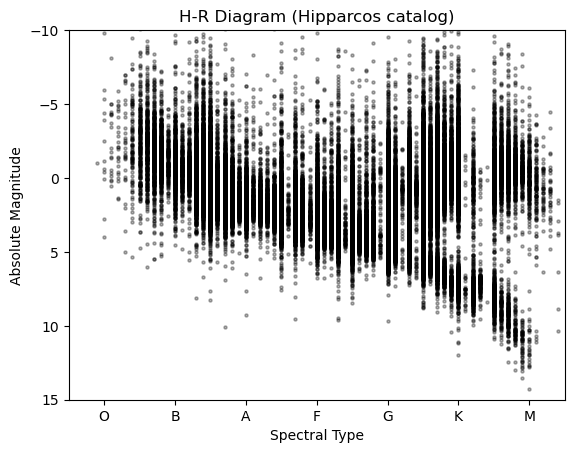

In [421]:
# Your code here
plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s = 5, alpha = 0.3, c = 'k')
plt.xlim(0, 70)
plt.ylim(15, -10)
plt.xticks(range(5, 75, 10))
plt.gca().set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

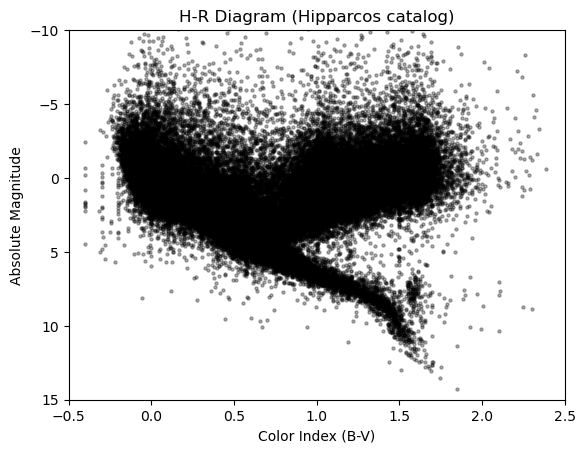

In [425]:
plt.scatter(df_clean['B-V'], df_clean['M_V'], s = 5, alpha = 0.3, c = 'k')
plt.xlim(-.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

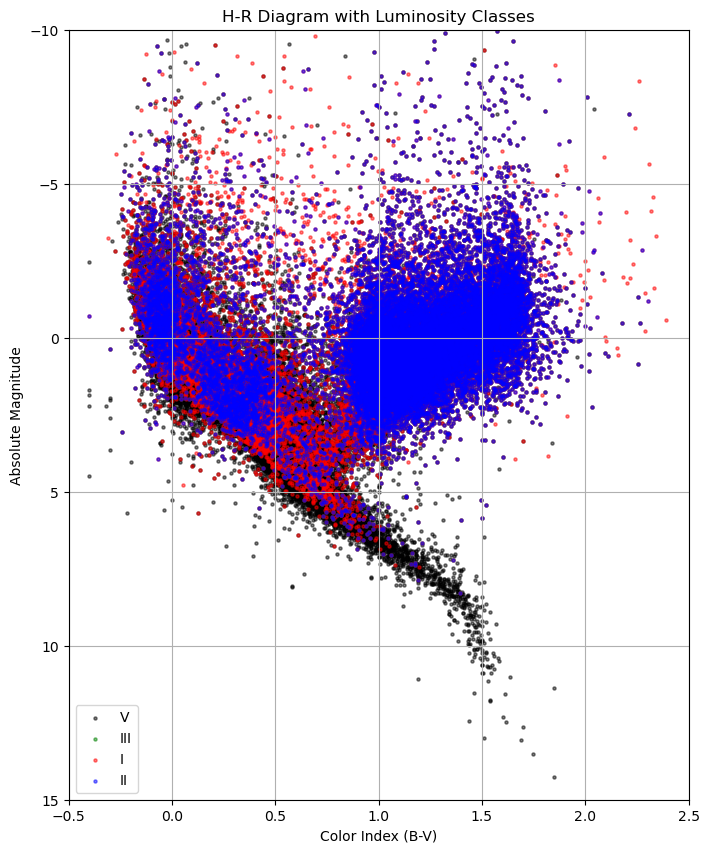

In [435]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

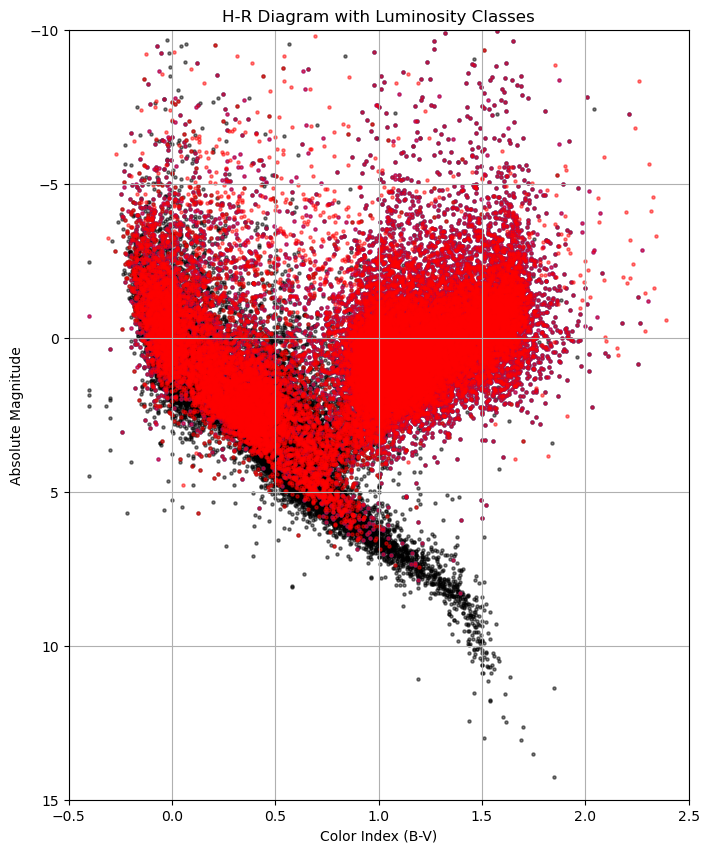

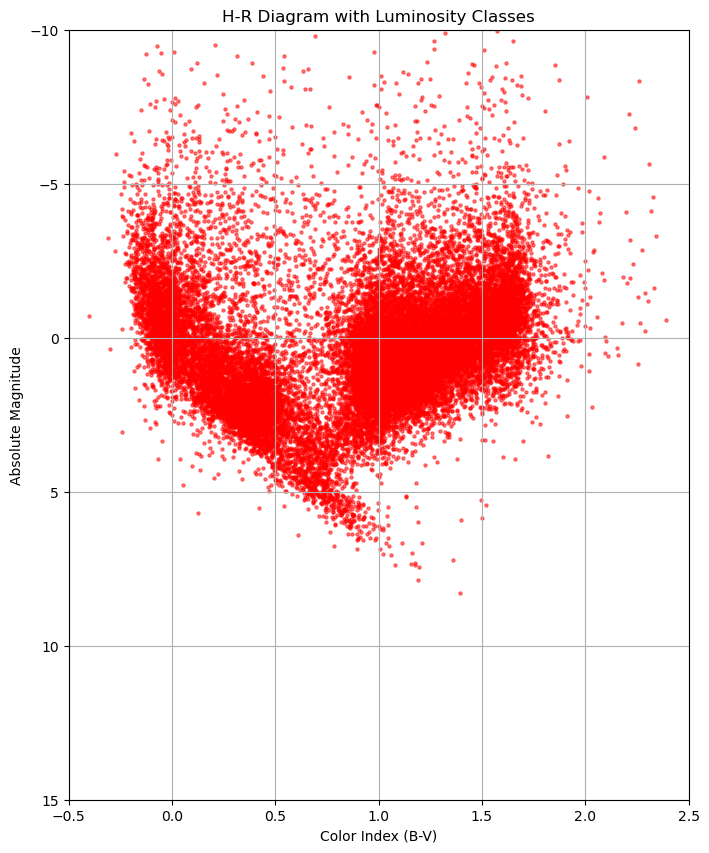

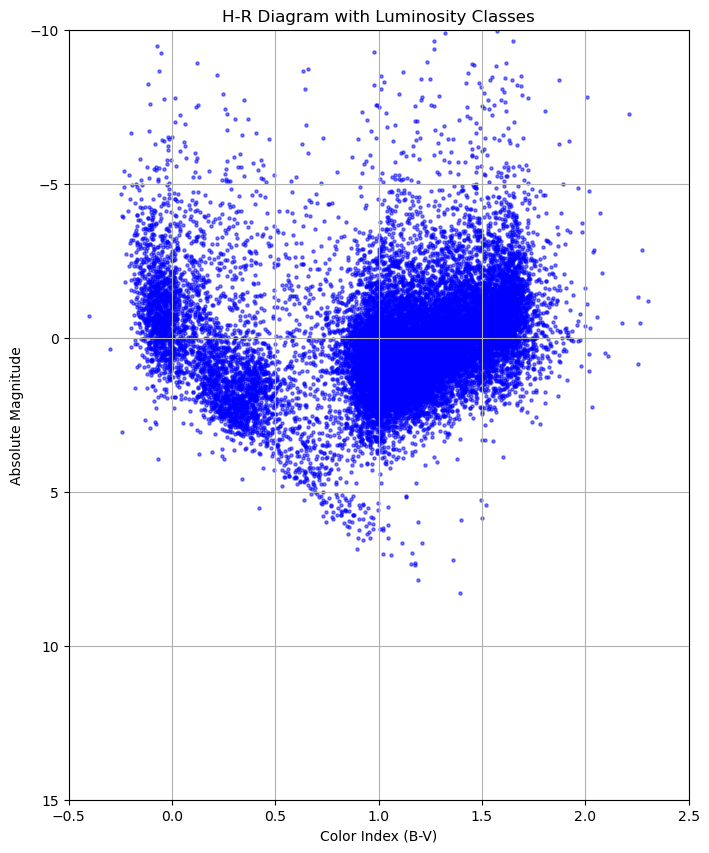

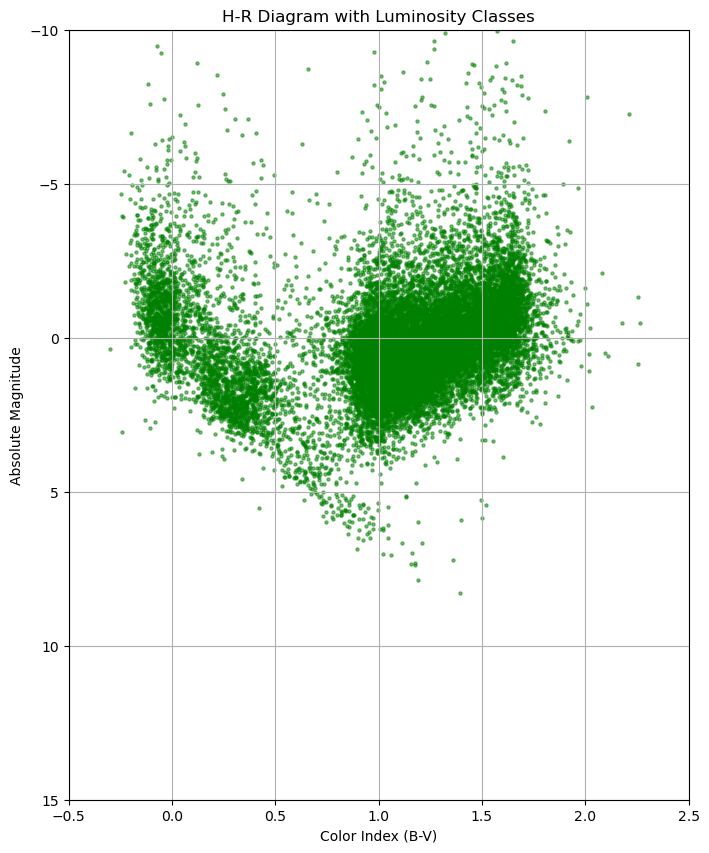

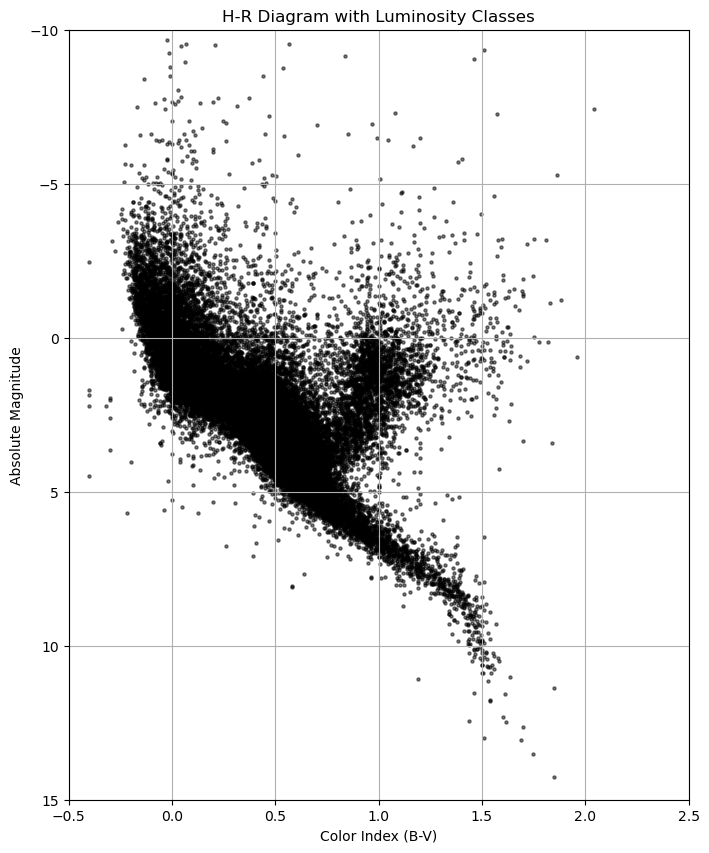

In [447]:
# Your code here

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plt.show()

# Your code here

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

#plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
#plot_luminosity_class(df_clean, 'III', 'green')  # Giants
#plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plt.show()

# Your code here

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

#plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
#plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
#plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plt.show()

# Your code here

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

#plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
#plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
#plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plt.show()

# Your code here

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
#plot_luminosity_class(df_clean, 'III', 'green')  # Giants
#plot_luminosity_class(df_clean, 'II', 'blue')  # Bright Giants
#plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plt.show()

Submit your FITS file and this notebook to Gradescope!